In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/Pharma_Industry.csv")

df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [8]:
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [9]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [10]:
df["Drug Response"].value_counts()

Drug Response
1    260
0    240
Name: count, dtype: int64

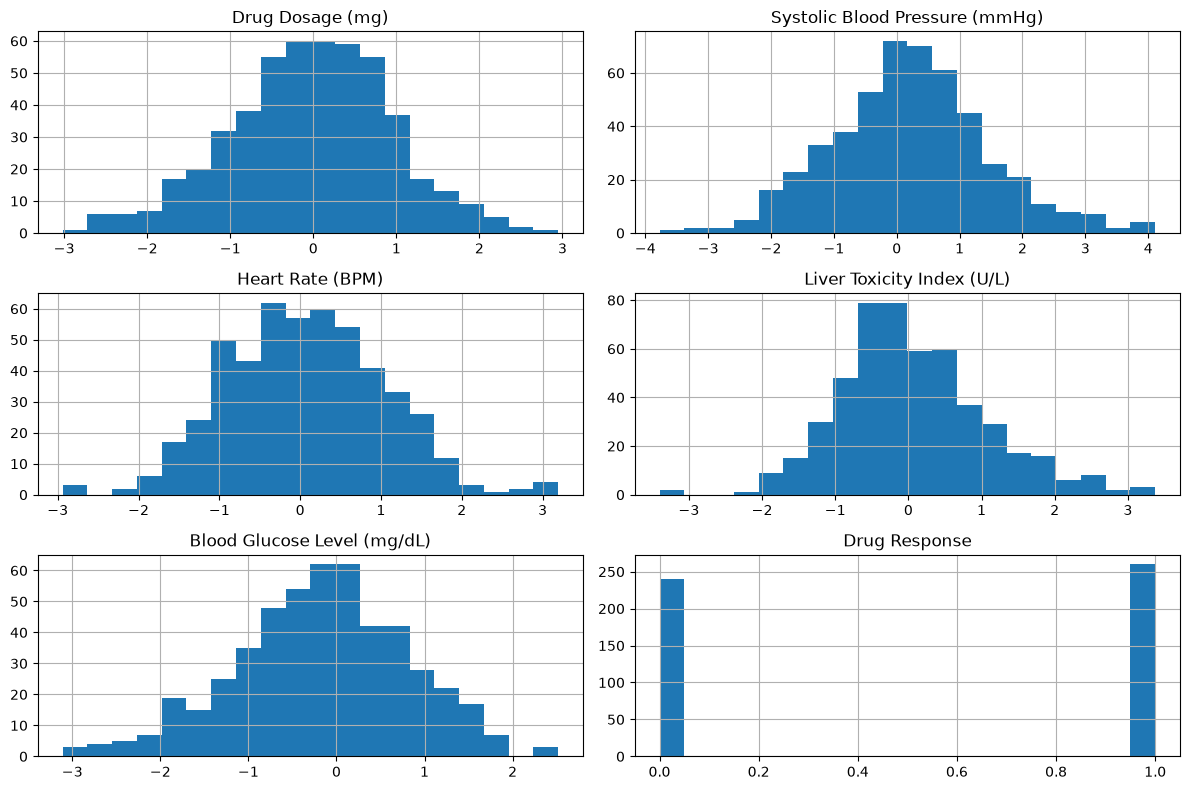

In [11]:
df.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

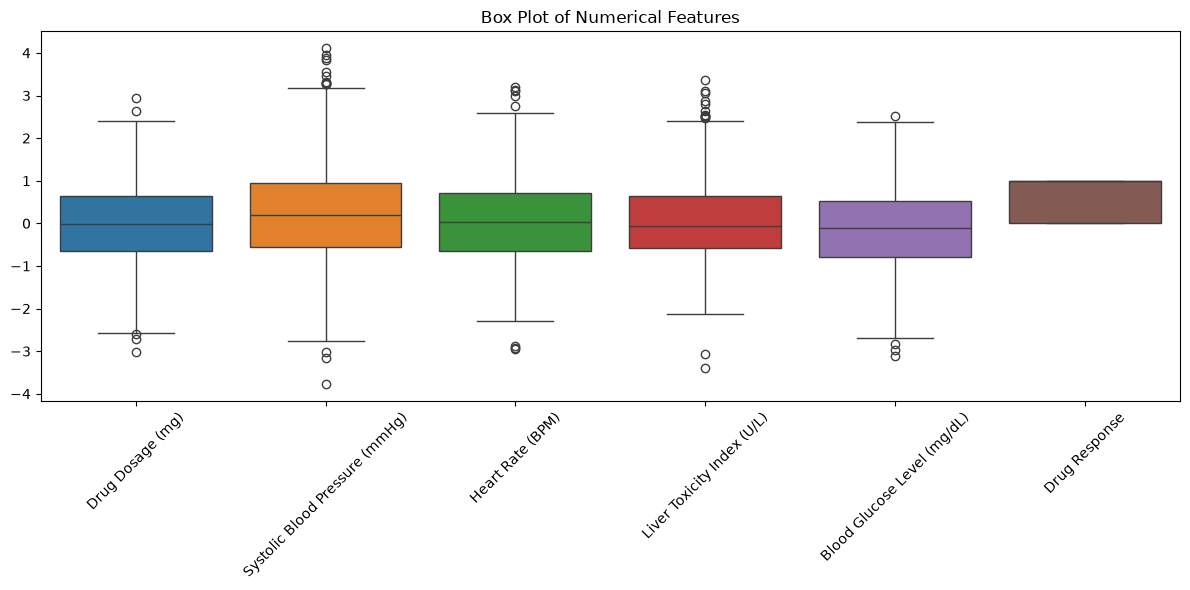

In [12]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df)

plt.xticks(rotation=45)
plt.title("Box Plot of Numerical Features")
plt.tight_layout()
plt.show()

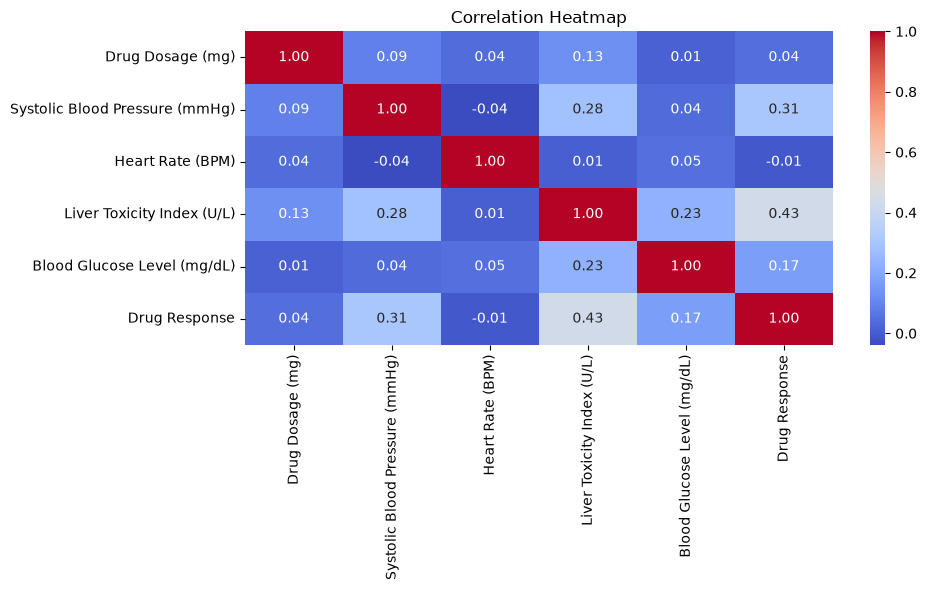

In [13]:
plt.figure(figsize=(10, 6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [14]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (500, 6)

Missing Values:
Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

Duplicate Rows: 0

Data Types:
Drug Dosage (mg)                  float64
Systolic Blood Pressure (mmHg)    float64
Heart Rate (BPM)                  float64
Liver Toxicity Index (U/L)        float64
Blood Glucose Level (mg/dL)       float64
Drug Response                       int64
dtype: object


In [15]:
X = df.drop("Drug Response", axis=1)
y = df["Drug Response"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0         -0.128538                        0.303280         -1.881849   
1         -1.846188                        2.865142         -0.929511   
2         -1.252393                       -1.541613          0.363632   
3          1.992515                       -1.142779         -0.766657   
4          0.377100                        0.538410         -0.029263   

   Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  
0                    0.258286                    -0.792011  
1                    2.866786                    -0.719447  
2                   -0.325370                     0.191314  
3                    0.975286                    -0.823355  
4                    1.896015                    -0.960130  

Target (y):
0    1
1    1
2    0
3    1
4    1
Name: Drug Response, dtype: int64


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (400, 5)
Testing set: (100, 5)


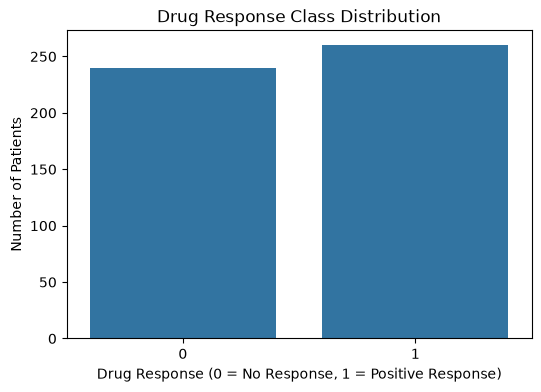

In [18]:
plt.figure(figsize=(6, 4))

sns.countplot(x=y)

plt.title("Drug Response Class Distribution")
plt.xlabel("Drug Response (0 = No Response, 1 = Positive Response)")
plt.ylabel("Number of Patients")

plt.show()

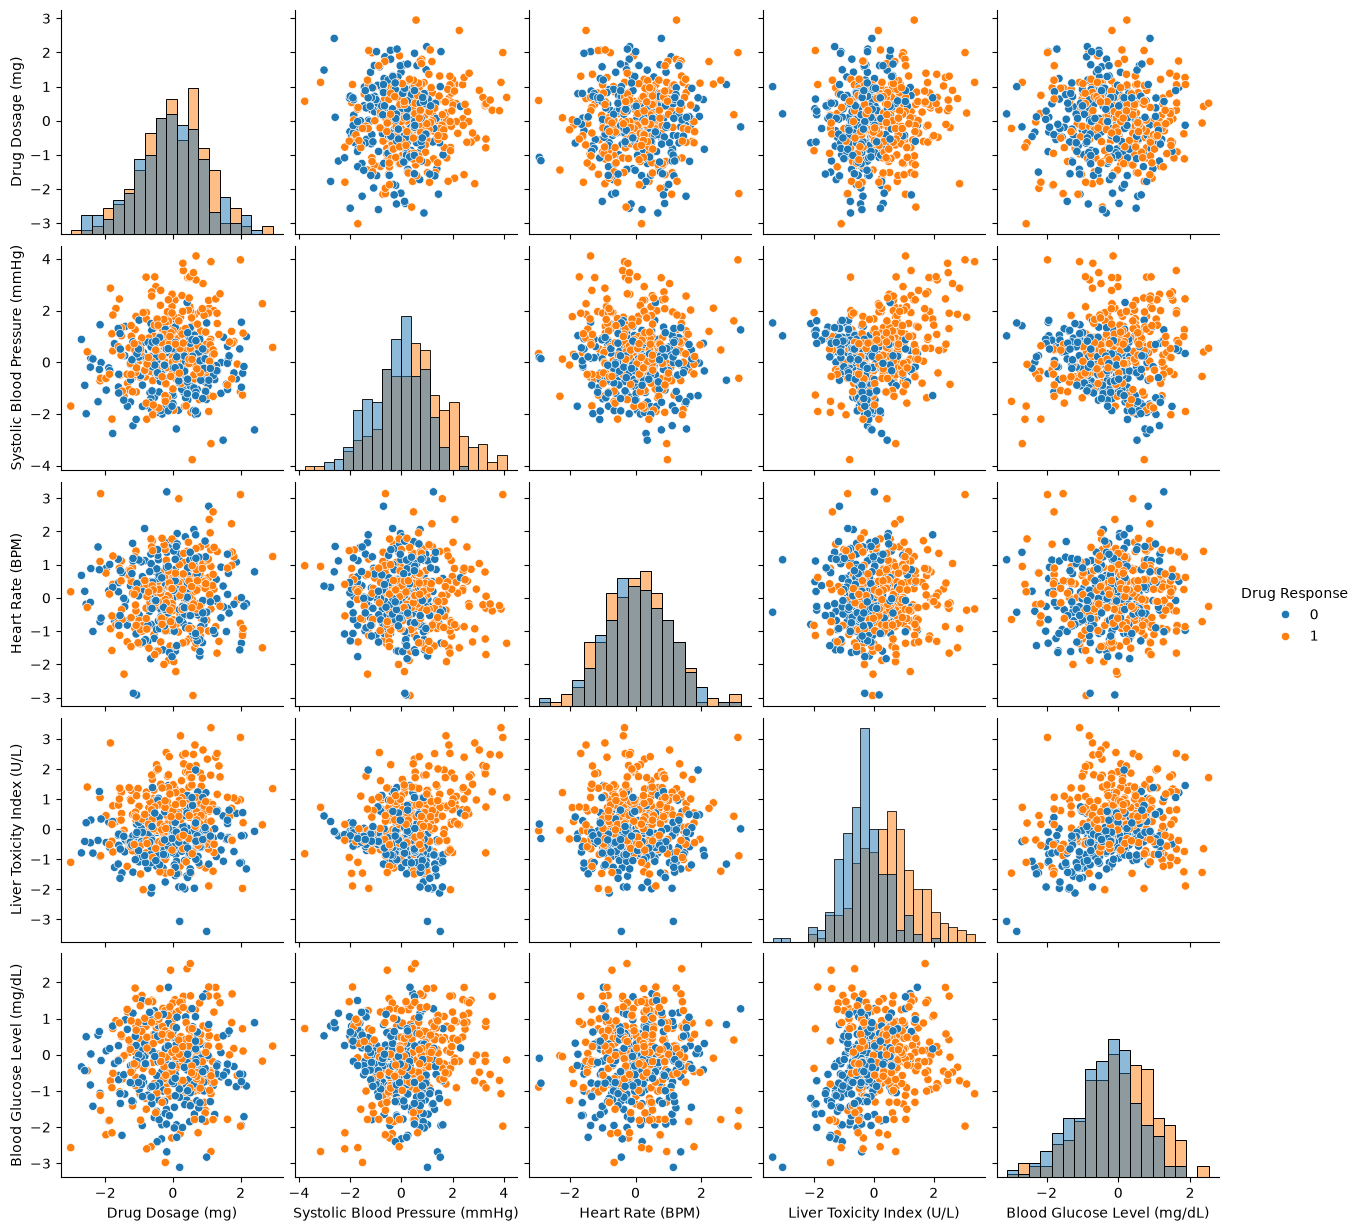

In [19]:
sns.pairplot(
    df,
    hue="Drug Response",
    diag_kind="hist"
)

plt.show()

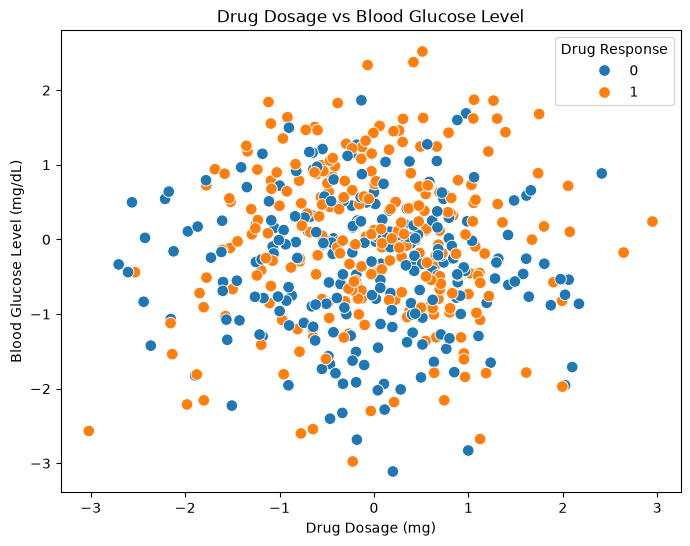

In [20]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Drug Dosage (mg)",
    y="Blood Glucose Level (mg/dL)",
    hue="Drug Response",
    s=70
)

plt.title("Drug Dosage vs Blood Glucose Level")
plt.xlabel("Drug Dosage (mg)")
plt.ylabel("Blood Glucose Level (mg/dL)")

plt.show()

In [21]:
from sklearn.svm import SVC

svm_model = SVC(kernel="linear", random_state=42)

svm_model.fit(X_train, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


In [22]:
y_pred = svm_model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[1 1 1 0 0 1 1 0 1 1 1 0 0 1 0 1 0 0 0 0 0 0 0 1 0 1 0 0 1 1 1 1 1 0 0 0 1
 0 0 1 1 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 1 1 0 0 0 0 1 0 0 0 0 1 1 1 0 0
 1 1 0 1 0 1 0 1 0 1 1 1 1 1 0 0 0 0 0 1 0 1 1 1 1 1]


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.72
Precision: 0.7608695652173914
Recall   : 0.6730769230769231
F1-Score : 0.7142857142857143


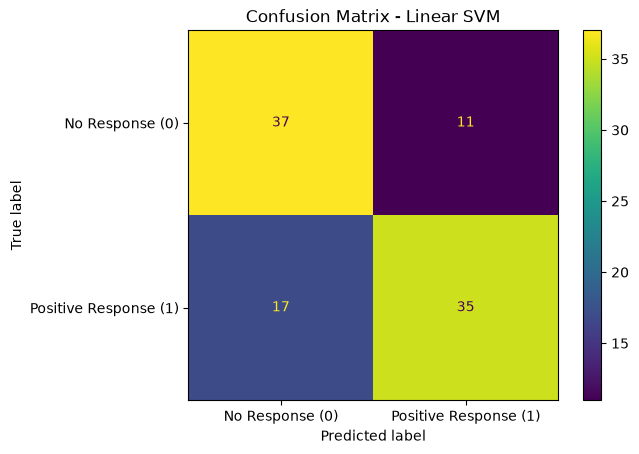

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Response (0)", "Positive Response (1)"]
)

disp.plot()
plt.title("Confusion Matrix - Linear SVM")
plt.show()

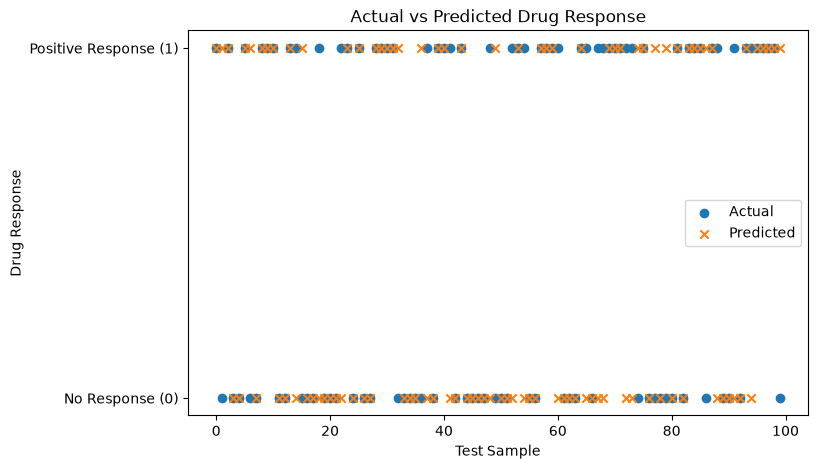

In [25]:
plt.figure(figsize=(8, 5))

plt.scatter(
    range(len(y_test)),
    y_test,
    label="Actual",
    marker="o"
)

plt.scatter(
    range(len(y_pred)),
    y_pred,
    label="Predicted",
    marker="x"
)

plt.title("Actual vs Predicted Drug Response")
plt.xlabel("Test Sample")
plt.ylabel("Drug Response")
plt.yticks([0, 1], ["No Response (0)", "Positive Response (1)"])
plt.legend()

plt.show()

In [26]:
from sklearn.svm import SVC

# Linear Kernel
svm_linear = SVC(kernel="linear", random_state=42)
svm_linear.fit(X_train, y_train)

# Polynomial Kernel
svm_poly = SVC(kernel="poly", random_state=42)
svm_poly.fit(X_train, y_train)

# RBF Kernel
svm_rbf = SVC(kernel="rbf", random_state=42)
svm_rbf.fit(X_train, y_train)

print("All three SVM models trained successfully.")

All three SVM models trained successfully.


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Linear": svm_linear,
    "Polynomial": svm_poly,
    "RBF": svm_rbf
}

results = []

for name, model in models.items():
    predictions = model.predict(X_test)

    results.append({
        "Kernel": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1-Score": f1_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)

print(results_df)

       Kernel  Accuracy  Precision    Recall  F1-Score
0      Linear      0.72   0.760870  0.673077  0.714286
1  Polynomial      0.72   0.772727  0.653846  0.708333
2         RBF      0.78   0.767857  0.826923  0.796296


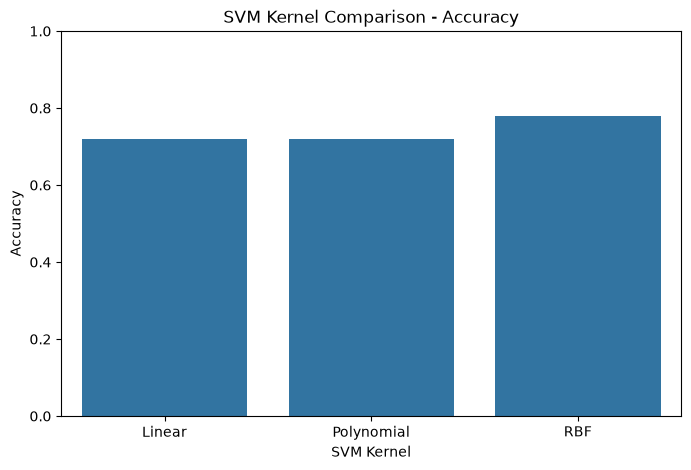

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="Kernel",
    y="Accuracy"
)

plt.title("SVM Kernel Comparison - Accuracy")
plt.xlabel("SVM Kernel")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

In [29]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.1, 1]
}

grid_search = GridSearchCV(
    SVC(kernel="rbf"),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'C': 10, 'gamma': 'scale'}
Best Cross-Validation Accuracy: 0.7725000000000002


In [30]:
best_svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    random_state=42
)

best_svm.fit(X_train, y_train)

best_pred = best_svm.predict(X_test)

print("Optimized RBF SVM trained successfully.")

Optimized RBF SVM trained successfully.


In [31]:
optimized_accuracy = accuracy_score(y_test, best_pred)
optimized_precision = precision_score(y_test, best_pred)
optimized_recall = recall_score(y_test, best_pred)
optimized_f1 = f1_score(y_test, best_pred)

print("Optimized RBF SVM Results")
print("-------------------------")
print("Accuracy :", optimized_accuracy)
print("Precision:", optimized_precision)
print("Recall   :", optimized_recall)
print("F1-Score :", optimized_f1)

Optimized RBF SVM Results
-------------------------
Accuracy : 0.73
Precision: 0.7272727272727273
Recall   : 0.7692307692307693
F1-Score : 0.7476635514018691


In [32]:
print("SVM Kernel Performance Comparison")
print("----------------------------------")
print(results_df)

SVM Kernel Performance Comparison
----------------------------------
       Kernel  Accuracy  Precision    Recall  F1-Score
0      Linear      0.72   0.760870  0.673077  0.714286
1  Polynomial      0.72   0.772727  0.653846  0.708333
2         RBF      0.78   0.767857  0.826923  0.796296


In [33]:
best_kernel = results_df.loc[
    results_df["Accuracy"].idxmax()
]

print("Best Performing Kernel:")
print(best_kernel)

Best Performing Kernel:
Kernel            RBF
Accuracy         0.78
Precision    0.767857
Recall       0.826923
F1-Score     0.796296
Name: 2, dtype: object


In [34]:
from sklearn.metrics import classification_report

print("Classification Report - Optimized RBF SVM")
print(classification_report(
    y_test,
    best_pred,
    target_names=["No Response (0)", "Positive Response (1)"]
))

Classification Report - Optimized RBF SVM
                       precision    recall  f1-score   support

      No Response (0)       0.73      0.69      0.71        48
Positive Response (1)       0.73      0.77      0.75        52

             accuracy                           0.73       100
            macro avg       0.73      0.73      0.73       100
         weighted avg       0.73      0.73      0.73       100

